# Encrenaz Averaging

In [2]:
import numpy as np
import matplotlib
from matplotlib import rc
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy
import scipy.io as sio
import csv
from scipy.io import readsav
from scipy.ndimage import shift
from scipy.ndimage import gaussian_filter
from scipy import interpolate
import pandas as pd
from bokeh.io import push_notebook, show, output_notebook
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Label, LabelSet,BoxAnnotation, Range1d
from astropy.io import fits
import pandas as pd 
output_notebook()

NORMALIZATION_INDEX = 800

Loading BokehJS ...

# Headers

## File One

In [3]:
encrenaz_file_1 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8038.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_1) as hdu_list:
    encrenaz_object_info_1= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_1 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_1= hdu_list[1].header #store extracted header
    encrenaz_sky_header_1= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_1= hdu_list[3].header #store noise header

    encrenaz_primary_1=hdu_list[0]
    
    encrenaz_wavenumber_1 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_1.tolist() #make it into a list

    encrenaz_image_data_1=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_1= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8038.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 47)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


In [4]:
print(encrenaz_primary_header_1)

SIMPLE  =                    T                                                  BITPIX  =                  -32                                                  NAXIS   =                    3                                                  NAXIS1  =                 1792                                                  NAXIS2  =                   32                                                  NAXIS3  =                   47                                                  EXTEND  =                    T                                                  COMMENT   The primary data unit contains a spectral-spatial-spatial             COMMENT    data cube                                                            COMMENT   The primary HDU is followed by a table extension                      COMMENT   (EXTNAME = EXTRACTED)                                                 COMMENT   giving the observed vacuum wavenumbers,                               COMMENT   flux through the slit, estimat

## File Two

In [5]:
encrenaz_file_2 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8039.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_2) as hdu_list:
    encrenaz_object_info_2= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_2 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_2= hdu_list[1].header #store extracted header
    encrenaz_sky_header_2= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_2= hdu_list[3].header #store noise header

    encrenaz_primary_2=hdu_list[0]
    
    encrenaz_wavenumber_2 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_2.tolist() #make it into a list

    encrenaz_image_data_2=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_2= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8039.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 49)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


In [6]:
print(encrenaz_primary_header_2)

SIMPLE  =                    T                                                  BITPIX  =                  -32                                                  NAXIS   =                    3                                                  NAXIS1  =                 1792                                                  NAXIS2  =                   32                                                  NAXIS3  =                   49                                                  EXTEND  =                    T                                                  COMMENT   The primary data unit contains a spectral-spatial-spatial             COMMENT    data cube                                                            COMMENT   The primary HDU is followed by a table extension                      COMMENT   (EXTNAME = EXTRACTED)                                                 COMMENT   giving the observed vacuum wavenumbers,                               COMMENT   flux through the slit, estimat

## File Three

In [5]:
encrenaz_file_3 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8040.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_3) as hdu_list:
    encrenaz_object_info_3= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_3 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_3= hdu_list[1].header #store extracted header
    encrenaz_sky_header_3= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_3= hdu_list[3].header #store noise header

    encrenaz_primary_3=hdu_list[0]
    
    encrenaz_wavenumber_3 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_3.tolist() #make it into a list

    encrenaz_image_data_3=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_3= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8040.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 47)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


## File Four

In [6]:
encrenaz_file_4 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8041.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_4) as hdu_list:
    encrenaz_object_info_4= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_4 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_4= hdu_list[1].header #store extracted header
    encrenaz_sky_header_4= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_4= hdu_list[3].header #store noise header

    encrenaz_primary_4=hdu_list[0]
    
    encrenaz_wavenumber_4 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_4.tolist() #make it into a list

    encrenaz_image_data_4=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_4= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8041.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (768, 64, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   768R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (768, 64)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (768, 64)   float32   


## File Five

In [7]:
encrenaz_file_5 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8042.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_5) as hdu_list:
    encrenaz_object_info_5= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_5 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_5= hdu_list[1].header #store extracted header
    encrenaz_sky_header_5= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_5= hdu_list[3].header #store noise header

    encrenaz_primary_5=hdu_list[0]
    
    encrenaz_wavenumber_5 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_5.tolist() #make it into a list

    encrenaz_image_data_5=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_5= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8042.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (768, 64, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   768R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (768, 64)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (768, 64)   float32   


## File Six 

In [8]:
encrenaz_file_6 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8044.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_6) as hdu_list:
    encrenaz_object_info_6= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_6 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_6= hdu_list[1].header #store extracted header
    encrenaz_sky_header_6= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_6= hdu_list[3].header #store noise header

    encrenaz_primary_6=hdu_list[0]
    
    encrenaz_wavenumber_6 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_6.tolist() #make it into a list

    encrenaz_image_data_6=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_6= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8044.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     142   (2304, 26, 41)   float32   
  1  EXTRACTED     1 TableHDU        31   2304R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2304, 26)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2304, 26)   float32   


## File Seven

In [9]:
encrenaz_file_7 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8045.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_7) as hdu_list:
    encrenaz_object_info_7= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_7 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_7= hdu_list[1].header #store extracted header
    encrenaz_sky_header_7= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_7= hdu_list[3].header #store noise header

    encrenaz_primary_7=hdu_list[0]
    
    encrenaz_wavenumber_7 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_7.tolist() #make it into a list

    encrenaz_image_data_7=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_7= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8045.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     142   (2304, 26, 43)   float32   
  1  EXTRACTED     1 TableHDU        31   2304R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2304, 26)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2304, 26)   float32   


## File Eight

In [10]:
encrenaz_file_8 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8046.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_8) as hdu_list:
    encrenaz_object_info_8= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_8 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_8= hdu_list[1].header #store extracted header
    encrenaz_sky_header_8= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_8= hdu_list[3].header #store noise header

    encrenaz_primary_8=hdu_list[0]
    
    encrenaz_wavenumber_8 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_8.tolist() #make it into a list

    encrenaz_image_data_8=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_8= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8046.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     142   (2304, 26, 41)   float32   
  1  EXTRACTED     1 TableHDU        31   2304R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (2304, 26)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (2304, 26)   float32   


## File Nine

In [11]:
encrenaz_file_9 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8047.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_9) as hdu_list:
    encrenaz_object_info_9= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_9 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_9= hdu_list[1].header #store extracted header
    encrenaz_sky_header_9= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_9= hdu_list[3].header #store noise header

    encrenaz_primary_9=hdu_list[0]
    
    encrenaz_wavenumber_9 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_9.tolist() #make it into a list

    encrenaz_image_data_9=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_9= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8047.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1280, 43, 41)   float32   
  1  EXTRACTED     1 TableHDU        31   1280R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1280, 43)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1280, 43)   float32   


## File Ten

In [12]:
encrenaz_file_10 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8048.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_10) as hdu_list:
    encrenaz_object_info_10= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_10 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_10= hdu_list[1].header #store extracted header
    encrenaz_sky_header_10= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_10= hdu_list[3].header #store noise header

    encrenaz_primary_10=hdu_list[0]
    
    encrenaz_wavenumber_10 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_10.tolist() #make it into a list

    encrenaz_image_data_10=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_10= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8048.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1280, 43, 41)   float32   
  1  EXTRACTED     1 TableHDU        31   1280R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1280, 43)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1280, 43)   float32   


## File Eleven 

In [13]:
encrenaz_file_11 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8049.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_11) as hdu_list:
    encrenaz_object_info_11= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_11 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_11= hdu_list[1].header #store extracted header
    encrenaz_sky_header_11= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_11= hdu_list[3].header #store noise header

    encrenaz_primary_11=hdu_list[0]
    
    encrenaz_wavenumber_11 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_11.tolist() #make it into a list

    encrenaz_image_data_11=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_11= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8049.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 47)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


## File Twelve

In [14]:
encrenaz_file_12 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8050.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_12) as hdu_list:
    encrenaz_object_info_12= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_12 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_12= hdu_list[1].header #store extracted header
    encrenaz_sky_header_12= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_12= hdu_list[3].header #store noise header

    encrenaz_primary_12=hdu_list[0]
    
    encrenaz_wavenumber_12 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_12.tolist() #make it into a list

    encrenaz_image_data_12=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_12= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8050.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 49)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


## File Thirteen

In [15]:
encrenaz_file_13 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8051.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_13) as hdu_list:
    encrenaz_object_info_13= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_13 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_13= hdu_list[1].header #store extracted header
    encrenaz_sky_header_13= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_13= hdu_list[3].header #store noise header

    encrenaz_primary_13=hdu_list[0]
    
    encrenaz_wavenumber_13 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_13.tolist() #make it into a list

    encrenaz_image_data_13=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_13= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8051.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 47)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


## File Fourteen

In [16]:
encrenaz_file_14 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8052.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_14) as hdu_list:
    encrenaz_object_info_14= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_14 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_14= hdu_list[1].header #store extracted header
    encrenaz_sky_header_14= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_14= hdu_list[3].header #store noise header

    encrenaz_primary_14=hdu_list[0]
    
    encrenaz_wavenumber_14 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_14.tolist() #make it into a list

    encrenaz_image_data_14=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_14= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8052.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (768, 64, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   768R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (768, 64)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (768, 64)   float32   


## File Fifteen

In [17]:
encrenaz_file_15 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8052.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_15) as hdu_list:
    encrenaz_object_info_15= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_15 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_15= hdu_list[1].header #store extracted header
    encrenaz_sky_header_15= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_15= hdu_list[3].header #store noise header

    encrenaz_primary_15=hdu_list[0]
    
    encrenaz_wavenumber_15 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_15.tolist() #make it into a list

    encrenaz_image_data_15=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_15= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8052.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (768, 64, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   768R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (768, 64)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (768, 64)   float32   


## File Sixteen

In [18]:
encrenaz_file_16 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8053.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_16) as hdu_list:
    encrenaz_object_info_16= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_16 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_16= hdu_list[1].header #store extracted header
    encrenaz_sky_header_16= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_16= hdu_list[3].header #store noise header

    encrenaz_primary_16=hdu_list[0]
    
    encrenaz_wavenumber_16 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_16.tolist() #make it into a list

    encrenaz_image_data_16=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_16= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8053.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (768, 64, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   768R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (768, 64)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (768, 64)   float32   


## File Seventeen

In [19]:
encrenaz_file_17 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8054.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_17) as hdu_list:
    encrenaz_object_info_17= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_17 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_17= hdu_list[1].header #store extracted header
    encrenaz_sky_header_17= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_17= hdu_list[3].header #store noise header

    encrenaz_primary_17=hdu_list[0]
    
    encrenaz_wavenumber_17 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_17.tolist() #make it into a list

    encrenaz_image_data_17=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_17= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8054.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1280, 43, 43)   float32   
  1  EXTRACTED     1 TableHDU        31   1280R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1280, 43)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1280, 43)   float32   


## File Eighteen

In [20]:
encrenaz_file_18 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8055.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_18) as hdu_list:
    encrenaz_object_info_18= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_18 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_18= hdu_list[1].header #store extracted header
    encrenaz_sky_header_18= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_18= hdu_list[3].header #store noise header

    encrenaz_primary_18=hdu_list[0]
    
    encrenaz_wavenumber_18 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_18.tolist() #make it into a list

    encrenaz_image_data_18=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_18= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8055.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1280, 43, 43)   float32   
  1  EXTRACTED     1 TableHDU        31   1280R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1280, 43)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1280, 43)   float32   


## File Nineteen

In [21]:
encrenaz_file_19 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8056.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_19) as hdu_list:
    encrenaz_object_info_19= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_19 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_19= hdu_list[1].header #store extracted header
    encrenaz_sky_header_19= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_19= hdu_list[3].header #store noise header

    encrenaz_primary_19=hdu_list[0]
    
    encrenaz_wavenumber_19 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_19.tolist() #make it into a list

    encrenaz_image_data_19=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_19= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8056.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 47)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


## File Twenty

In [22]:
encrenaz_file_20 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8057.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_20) as hdu_list:
    encrenaz_object_info_20= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_20 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_20= hdu_list[1].header #store extracted header
    encrenaz_sky_header_20= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_20= hdu_list[3].header #store noise header

    encrenaz_primary_20=hdu_list[0]
    
    encrenaz_wavenumber_20 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_20.tolist() #make it into a list

    encrenaz_image_data_20=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_20= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8057.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 49)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


## File Twenty One

In [23]:
encrenaz_file_21 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8058.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_21) as hdu_list:
    encrenaz_object_info_21= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_21 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_21= hdu_list[1].header #store extracted header
    encrenaz_sky_header_21= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_21= hdu_list[3].header #store noise header

    encrenaz_primary_21=hdu_list[0]
    
    encrenaz_wavenumber_21 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_21.tolist() #make it into a list

    encrenaz_image_data_21=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_21= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8058.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 47)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


## File Twenty Two

In [24]:
encrenaz_file_22 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8059.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_22) as hdu_list:
    encrenaz_object_info_22= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_22 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_22= hdu_list[1].header #store extracted header
    encrenaz_sky_header_22= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_22= hdu_list[3].header #store noise header

    encrenaz_primary_22=hdu_list[0]
    
    encrenaz_wavenumber_22 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_22.tolist() #make it into a list

    encrenaz_image_data_22=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_22= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8059.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (768, 64, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   768R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (768, 64)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (768, 64)   float32   


## File Twenty Three

In [25]:
encrenaz_file_23 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8060.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_23) as hdu_list:
    encrenaz_object_info_23= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_23 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_23= hdu_list[1].header #store extracted header
    encrenaz_sky_header_23= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_23= hdu_list[3].header #store noise header

    encrenaz_primary_23=hdu_list[0]
    
    encrenaz_wavenumber_23 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_23.tolist() #make it into a list

    encrenaz_image_data_23=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_23= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8060.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (768, 64, 37)   float32   
  1  EXTRACTED     1 TableHDU        31   768R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (768, 64)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (768, 64)   float32   


## File Twenty Four

In [26]:
encrenaz_file_24 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8061.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_24) as hdu_list:
    encrenaz_object_info_24= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_24 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_24= hdu_list[1].header #store extracted header
    encrenaz_sky_header_24= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_24= hdu_list[3].header #store noise header

    encrenaz_primary_24=hdu_list[0]
    
    encrenaz_wavenumber_24 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_24.tolist() #make it into a list

    encrenaz_image_data_24=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_24= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8061.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1280, 43, 43)   float32   
  1  EXTRACTED     1 TableHDU        31   1280R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1280, 43)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1280, 43)   float32   


## File Twenty Five 

In [27]:
encrenaz_file_25 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8062.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_25) as hdu_list:
    encrenaz_object_info_25= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_25 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_25= hdu_list[1].header #store extracted header
    encrenaz_sky_header_25= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_25= hdu_list[3].header #store noise header

    encrenaz_primary_25=hdu_list[0]
    
    encrenaz_wavenumber_25 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_25.tolist() #make it into a list

    encrenaz_image_data_25=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_25= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8062.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1280, 43, 43)   float32   
  1  EXTRACTED     1 TableHDU        31   1280R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1280, 43)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1280, 43)   float32   


## File Twenty Six

In [28]:
encrenaz_file_26 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8063.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_26) as hdu_list:
    encrenaz_object_info_26= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_26 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_26= hdu_list[1].header #store extracted header
    encrenaz_sky_header_26= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_26= hdu_list[3].header #store noise header

    encrenaz_primary_26=hdu_list[0]
    
    encrenaz_wavenumber_26 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_26.tolist() #make it into a list

    encrenaz_image_data_26=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_26= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8063.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 47)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


## File Twenty Seven

In [29]:
encrenaz_file_27 = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/sep_27_2021/TX21B0928.4001.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(encrenaz_file_27) as hdu_list:
    encrenaz_object_info_27= hdu_list.info() #display the extensions of the fits file
    encrenaz_primary_header_27 = hdu_list[0].header #store primary header
    encrenaz_extracted_header_27= hdu_list[1].header #store extracted header
    encrenaz_sky_header_27= hdu_list[2].header #store sky header
    encrenaz_scan_noise_header_27= hdu_list[3].header #store noise header

    encrenaz_primary_27=hdu_list[0]
    
    encrenaz_wavenumber_27 = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    encrenaz_wavenumber_27.tolist() #make it into a list

    encrenaz_image_data_27=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    encrenaz_sky_27= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/sep_27_2021/TX21B0928.4001.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 57)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


In [30]:
print(encrenaz_primary_header_27)

SIMPLE  =                    T                                                  BITPIX  =                  -32                                                  NAXIS   =                    3                                                  NAXIS1  =                 1792                                                  NAXIS2  =                   32                                                  NAXIS3  =                   57                                                  EXTEND  =                    T                                                  COMMENT   The primary data unit contains a spectral-spatial-spatial             COMMENT    data cube                                                            COMMENT   The primary HDU is followed by a table extension                      COMMENT   (EXTNAME = EXTRACTED)                                                 COMMENT   giving the observed vacuum wavenumbers,                               COMMENT   flux through the slit, estimat

# FITS Spectra

## File One

In [31]:
encrenaz_spectrum_1 = np.sum(np.sum(encrenaz_image_data_1[12:21,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792

encrenaz_sky_bump_1=encrenaz_sky_1*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File One",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_1, encrenaz_spectrum_1, legend_label='venus', color='green')
q.line(encrenaz_wavenumber_1, encrenaz_sky_bump_1,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Two

In [32]:
encrenaz_spectrum_2 = np.sum(np.sum(encrenaz_image_data_2[12:21,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792

encrenaz_sky_bump_2=encrenaz_sky_2*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Two",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_2, encrenaz_spectrum_2, legend_label='venus', color='green')
q.line(encrenaz_wavenumber_2, encrenaz_sky_bump_2,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Three

In [33]:
encrenaz_spectrum_3 = np.sum(np.sum(encrenaz_image_data_3[12:21,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792

encrenaz_sky_bump_3=encrenaz_sky_3*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Three",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_3, encrenaz_spectrum_3, legend_label='venus', color='green')
q.line(encrenaz_wavenumber_3, encrenaz_sky_bump_3,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Eleven

In [34]:
encrenaz_spectrum_11 = np.sum(np.sum(encrenaz_image_data_11[12:21,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792

encrenaz_sky_bump_11=encrenaz_sky_11*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Eleven",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_11, encrenaz_spectrum_11, legend_label='venus', color='green')
q.line(encrenaz_wavenumber_11, encrenaz_sky_bump_11,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Twelve

In [35]:
encrenaz_spectrum_12 = np.sum(np.sum(encrenaz_image_data_12[12:21,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792

encrenaz_sky_bump_12=encrenaz_sky_12*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Twelve",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_12, encrenaz_spectrum_12, legend_label='venus', color='green')
q.line(encrenaz_wavenumber_12, encrenaz_sky_bump_12,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Thirteen

In [36]:
encrenaz_spectrum_13 = np.sum(np.sum(encrenaz_image_data_13[12:21,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792

encrenaz_sky_bump_13=encrenaz_sky_13*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Thirteen",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_13, encrenaz_spectrum_13, legend_label='venus', color='green')
q.line(encrenaz_wavenumber_13, encrenaz_sky_bump_13,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Nineteen

In [37]:
encrenaz_spectrum_19 = np.sum(np.sum(encrenaz_image_data_19[12:21,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792

encrenaz_sky_bump_19=encrenaz_sky_19*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Nineteen",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_19, encrenaz_spectrum_19, legend_label='venus', color='green')
q.line(encrenaz_wavenumber_19, encrenaz_sky_bump_19,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Twenty

In [38]:
encrenaz_spectrum_20 = np.sum(np.sum(encrenaz_image_data_20[12:21,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792

encrenaz_sky_bump_20=encrenaz_sky_20*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Twenty",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_20, encrenaz_spectrum_20, legend_label='venus', color='green')
q.line(encrenaz_wavenumber_20, encrenaz_sky_bump_20,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Twenty One

In [39]:
encrenaz_spectrum_21 = np.sum(np.sum(encrenaz_image_data_21[12:21,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792

encrenaz_sky_bump_21=encrenaz_sky_21*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Twenty One",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_21, encrenaz_spectrum_21, legend_label='venus', color='green')
q.line(encrenaz_wavenumber_21, encrenaz_sky_bump_21,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Twenty Six

In [40]:
encrenaz_spectrum_26 = np.sum(np.sum(encrenaz_image_data_26[12:21,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792

encrenaz_sky_bump_26=encrenaz_sky_26*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Twenty Six",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_26, encrenaz_spectrum_26, legend_label='venus', color='green')
q.line(encrenaz_wavenumber_26, encrenaz_sky_bump_26,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## FIle Twenty Seven

In [41]:
encrenaz_spectrum_27 = np.sum(np.sum(encrenaz_image_data_27[12:21,7:26,0:1792],axis=0),axis=0) #if error, replace with 1792

encrenaz_sky_bump_27=encrenaz_sky_27*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits File Twenty Six",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_27, encrenaz_spectrum_27, legend_label='venus', color='green')
q.line(encrenaz_wavenumber_27, encrenaz_sky_bump_27,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

In [42]:
print()

# PSG Model

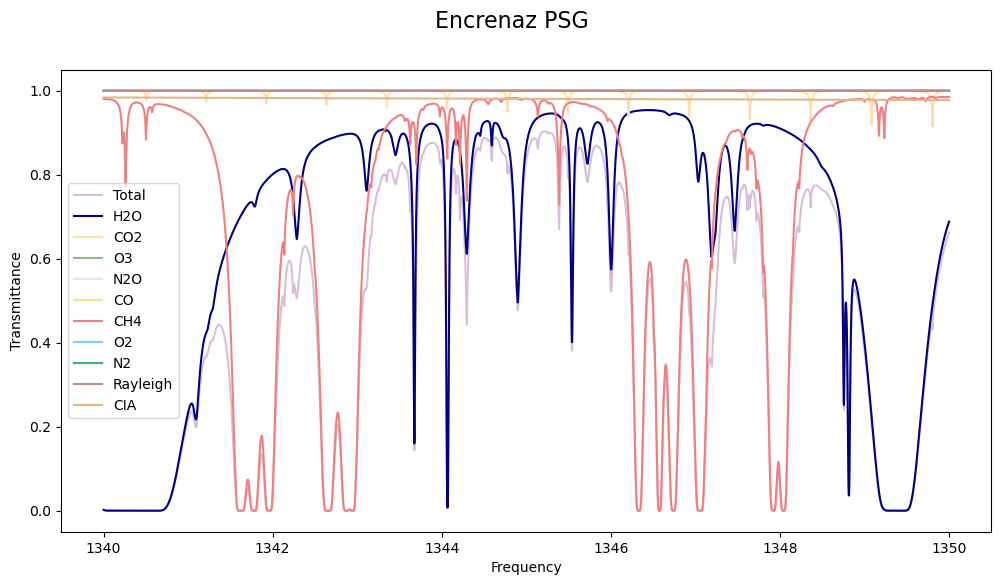

In [43]:
encrenaz_wavenumber = []
encrenaz_total_spectrum = []
encrenaz_H2O_spectrum = []
encrenaz_CO2_spectrum = []
encrenaz_O3_spectrum = []
encrenaz_N2O_spectrum = []
encrenaz_CO_spectrum = []
encrenaz_CH4_spectrum = []
encrenaz_O2_spectrum = []
encrenaz_N2_spectrum = []
encrenaz_SO2_spectrum = []
encrenaz_Rayleigh_spectrum = []
encrenaz_CIA_spectrum = []


with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - encrenaz.csv') as encrenaz_psg_file:  
    plots = csv.reader(encrenaz_psg_file, delimiter = ',') 
      
    for row in plots: 
        encrenaz_wavenumber.append(float(row[0]))
        encrenaz_total_spectrum.append(float(row[1]))
        encrenaz_H2O_spectrum.append(float(row[2]))
        encrenaz_CO2_spectrum.append(float(row[3]))
        encrenaz_O3_spectrum.append(float(row[4]))
        encrenaz_N2O_spectrum.append(float(row[5]))
        encrenaz_CO_spectrum.append(float(row[6]))
        encrenaz_CH4_spectrum.append(float(row[7]))
        encrenaz_O2_spectrum.append(float(row[8]))
        encrenaz_N2_spectrum.append(float(row[9]))
        encrenaz_Rayleigh_spectrum.append(float(row[10]))
        encrenaz_CIA_spectrum.append(float(row[11]))
        
fig, ax = plt.subplots(figsize=(12, 6))
plt.xlabel('Frequency')
plt.ylabel('Transmittance')
fig.suptitle('Encrenaz PSG', fontsize=16)


ax.plot(encrenaz_wavenumber,encrenaz_total_spectrum, label = 'Total', color='thistle')
ax.plot(encrenaz_wavenumber,encrenaz_H2O_spectrum, label = 'H2O', color='navy')
ax.plot(encrenaz_wavenumber,encrenaz_CO2_spectrum, label = 'CO2', color='navajowhite')
ax.plot(encrenaz_wavenumber,encrenaz_O3_spectrum, label = 'O3', color='darkseagreen')
ax.plot(encrenaz_wavenumber,encrenaz_N2O_spectrum, label = 'N2O', color='lavender')
ax.plot(encrenaz_wavenumber,encrenaz_CO_spectrum, label = 'CO',  color='khaki')
ax.plot(encrenaz_wavenumber,encrenaz_CH4_spectrum, label = 'CH4', color='lightcoral')
ax.plot(encrenaz_wavenumber,encrenaz_O2_spectrum, label = 'O2', color='lightskyblue')
ax.plot(encrenaz_wavenumber,encrenaz_N2_spectrum, label = 'N2', color='mediumseagreen')
ax.plot(encrenaz_wavenumber,encrenaz_Rayleigh_spectrum, label = 'Rayleigh', color='rosybrown')
ax.plot(encrenaz_wavenumber,encrenaz_CIA_spectrum, label = 'CIA', color='burlywood')

plt.legend()

plt.show()  

In [44]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Encrenaz PSG",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber, encrenaz_total_spectrum, legend_label='Total', color='thistle')
q.line(encrenaz_wavenumber, encrenaz_H2O_spectrum,legend_label='H2O', color='navy')
q.line(encrenaz_wavenumber, encrenaz_CO2_spectrum,legend_label='CO2', color='navajowhite')
q.line(encrenaz_wavenumber, encrenaz_O3_spectrum,legend_label='O3', color='darkseagreen')
q.line(encrenaz_wavenumber, encrenaz_N2O_spectrum,legend_label='N2O', color='lavender')
q.line(encrenaz_wavenumber, encrenaz_CO_spectrum,legend_label='CO', color='khaki')
q.line(encrenaz_wavenumber, encrenaz_CH4_spectrum,legend_label='CH4', color='lightcoral')
q.line(encrenaz_wavenumber, encrenaz_O2_spectrum,legend_label='O2', color='lightskyblue')
q.line(encrenaz_wavenumber, encrenaz_N2_spectrum,legend_label='N2', color='mediumseagreen')
q.line(encrenaz_wavenumber, encrenaz_Rayleigh_spectrum,legend_label='Rayleigh', color='rosybrown')
q.line(encrenaz_wavenumber, encrenaz_CIA_spectrum,legend_label='CIA', color='burlywood')

q.legend.location = "bottom_right"

show(q)

# Data Processing

## Variables

In [45]:
encrenaz_reversed = list(reversed(encrenaz_wavenumber))

encrenaz_H2O_reversed = list(reversed(encrenaz_H2O_spectrum))
encrenaz_CO2_reversed = list(reversed(encrenaz_CO2_spectrum))
encrenaz_CH4_reversed = list(reversed(encrenaz_CH4_spectrum))

## File One

In [46]:
encrenaz_exp_H2O_1 = 0.2 #exponent on water transmission
encrenaz_exp_CO2_1 = 0.3 #exponent on CO2 transmission
encrenaz_exp_CH4_1 = 0.15 #exponent on CH4 transmission

encrenaz_k_1 = 10 #Gaussian sigma of resolution broadening, in pixels

encrenaz_wavenumber_shift_1 = 0 #empirical wavenumber shift to improve residuals

In [47]:
encrenaz_H2O_exp_1=[]
encrenaz_CO2_exp_1=[]
encrenaz_CH4_exp_1=[]
for number in encrenaz_H2O_reversed:
    encrenaz_H2O_exp_1.append(number**encrenaz_exp_H2O_1)
for number in encrenaz_CO2_reversed:
    encrenaz_CO2_exp_1.append(number**encrenaz_exp_CO2_1)
for number in encrenaz_CH4_reversed:
    encrenaz_CH4_exp_1.append(number**encrenaz_exp_CH4_1)
    
encrenaz_total_1 = np.array(encrenaz_H2O_exp_1)*np.array(encrenaz_CH4_exp_1)*np.array(encrenaz_CO2_exp_1)

encrenaz_gaussian_1 = gaussian_filter(encrenaz_total_1,encrenaz_k_1)

encrenaz_interpolate_1 = scipy.interpolate.interp1d(encrenaz_reversed, encrenaz_gaussian_1)
encrenaz_interpolate_function_1 = encrenaz_interpolate_1(encrenaz_wavenumber_1)

encrenaz_telluric_1 = shift(encrenaz_interpolate_function_1, encrenaz_wavenumber_shift_1)

encrenaz_normalized_telluric_1 = encrenaz_telluric_1 / np.median(encrenaz_telluric_1)

In [48]:
encrenaz_normalized_spectrum_1 = encrenaz_spectrum_1 / np.median(encrenaz_spectrum_1)
encrenaz_sky_normalized_1 = encrenaz_sky_1 / np.median(encrenaz_sky_1)

encrenaz_processed_spectrum_1 = np.divide(encrenaz_normalized_spectrum_1, encrenaz_normalized_telluric_1)

In [49]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File One",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_1, encrenaz_normalized_telluric_1, legend_label='corrected telluric', color='orange')
q.line(encrenaz_wavenumber_1, encrenaz_processed_spectrum_1, legend_label='venus processed', color='green')
q.line(encrenaz_wavenumber_1, encrenaz_normalized_spectrum_1, legend_label='venus unprocessed', color='red')
q.line(encrenaz_wavenumber_1, encrenaz_sky_normalized_1,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Two

In [50]:
encrenaz_exp_H2O_2 = 0.25 #exponent on water transmission
encrenaz_exp_CO2_2 = 0.3 #exponent on CO2 transmission
encrenaz_exp_CH4_2 = 0.15 #exponent on CH4 transmission

encrenaz_k_2 = 10 #Gaussian sigma of resolution broadening, in pixels

encrenaz_wavenumber_shift_2 = 0 #empirical wavenumber shift to improve residuals

In [51]:
encrenaz_H2O_exp_2=[]
encrenaz_CO2_exp_2=[]
encrenaz_CH4_exp_2=[]
for number in encrenaz_H2O_reversed:
    encrenaz_H2O_exp_2.append(number**encrenaz_exp_H2O_2)
for number in encrenaz_CO2_reversed:
    encrenaz_CO2_exp_2.append(number**encrenaz_exp_CO2_2)
for number in encrenaz_CH4_reversed:
    encrenaz_CH4_exp_2.append(number**encrenaz_exp_CH4_2)
    
encrenaz_total_2 = np.array(encrenaz_H2O_exp_2)*np.array(encrenaz_CH4_exp_2)*np.array(encrenaz_CO2_exp_2)

encrenaz_gaussian_2 = gaussian_filter(encrenaz_total_2,encrenaz_k_2)

encrenaz_interpolate_2 = scipy.interpolate.interp1d(encrenaz_reversed, encrenaz_gaussian_2)
encrenaz_interpolate_function_2 = encrenaz_interpolate_2(encrenaz_wavenumber_2)

encrenaz_telluric_2 = shift(encrenaz_interpolate_function_2, encrenaz_wavenumber_shift_2)

encrenaz_normalized_telluric_2 = encrenaz_telluric_2 / np.median(encrenaz_telluric_2)

In [52]:
encrenaz_normalized_spectrum_2 = encrenaz_spectrum_2 / np.median(encrenaz_spectrum_2)
encrenaz_sky_normalized_2 = encrenaz_sky_2 / np.median(encrenaz_sky_2)

encrenaz_processed_spectrum_2 = np.divide(encrenaz_normalized_spectrum_2, encrenaz_normalized_telluric_2)

In [53]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Two",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_2, encrenaz_normalized_telluric_2, legend_label='corrected telluric', color='orange')
q.line(encrenaz_wavenumber_2, encrenaz_processed_spectrum_2, legend_label='venus processed', color='green')
q.line(encrenaz_wavenumber_2, encrenaz_normalized_spectrum_2, legend_label='venus unprocessed', color='red')
q.line(encrenaz_wavenumber_2, encrenaz_sky_normalized_2,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Three

In [54]:
encrenaz_exp_H2O_3 = 0.3 #exponent on water transmission
encrenaz_exp_CO2_3 = 0.3 #exponent on CO2 transmission
encrenaz_exp_CH4_3 = 0.15 #exponent on CH4 transmission

encrenaz_k_3 = 10 #Gaussian sigma of resolution broadening, in pixels

encrenaz_wavenumber_shift_3 = 0 #empirical wavenumber shift to improve residuals

In [55]:
encrenaz_H2O_exp_3=[]
encrenaz_CO2_exp_3=[]
encrenaz_CH4_exp_3=[]
for number in encrenaz_H2O_reversed:
    encrenaz_H2O_exp_3.append(number**encrenaz_exp_H2O_3)
for number in encrenaz_CO2_reversed:
    encrenaz_CO2_exp_3.append(number**encrenaz_exp_CO2_3)
for number in encrenaz_CH4_reversed:
    encrenaz_CH4_exp_3.append(number**encrenaz_exp_CH4_3)
    
encrenaz_total_3 = np.array(encrenaz_H2O_exp_3)*np.array(encrenaz_CH4_exp_3)*np.array(encrenaz_CO2_exp_3)

encrenaz_gaussian_3 = gaussian_filter(encrenaz_total_3,encrenaz_k_3)

encrenaz_interpolate_3 = scipy.interpolate.interp1d(encrenaz_reversed, encrenaz_gaussian_3)
encrenaz_interpolate_function_3 = encrenaz_interpolate_3(encrenaz_wavenumber_3)

encrenaz_telluric_3 = shift(encrenaz_interpolate_function_3, encrenaz_wavenumber_shift_3)
encrenaz_normalized_telluric_3 = encrenaz_telluric_3 / np.median(encrenaz_telluric_3)

In [56]:
encrenaz_normalized_spectrum_3 = encrenaz_spectrum_3 / np.median(encrenaz_spectrum_3)
encrenaz_sky_normalized_3 = encrenaz_sky_3 / np.median(encrenaz_sky_3)

encrenaz_processed_spectrum_3 = np.divide(encrenaz_normalized_spectrum_3, encrenaz_normalized_telluric_3)

In [57]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Three",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_3, encrenaz_normalized_telluric_3, legend_label='corrected telluric', color='orange')
q.line(encrenaz_wavenumber_3, encrenaz_processed_spectrum_3, legend_label='venus processed', color='green')
q.line(encrenaz_wavenumber_3, encrenaz_normalized_spectrum_3, legend_label='venus unprocessed', color='red')
q.line(encrenaz_wavenumber_3, encrenaz_sky_normalized_3,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Eleven

In [58]:
encrenaz_exp_H2O_11 = 0.25 #exponent on water transmission
encrenaz_exp_CO2_11 = 0.3 #exponent on CO2 transmission
encrenaz_exp_CH4_11 = 0.15 #exponent on CH4 transmission

encrenaz_k_11 = 10 #Gaussian sigma of resolution broadening, in pixels

encrenaz_wavenumber_shift_11 = 0 #empirical wavenumber shift to improve residuals

In [59]:
encrenaz_H2O_exp_11=[]
encrenaz_CO2_exp_11=[]
encrenaz_CH4_exp_11=[]
for number in encrenaz_H2O_reversed:
    encrenaz_H2O_exp_11.append(number**encrenaz_exp_H2O_11)
for number in encrenaz_CO2_reversed:
    encrenaz_CO2_exp_11.append(number**encrenaz_exp_CO2_11)
for number in encrenaz_CH4_reversed:
    encrenaz_CH4_exp_11.append(number**encrenaz_exp_CH4_11)
    
encrenaz_total_11 = np.array(encrenaz_H2O_exp_11)*np.array(encrenaz_CH4_exp_11)*np.array(encrenaz_CO2_exp_11)

encrenaz_gaussian_11 = gaussian_filter(encrenaz_total_11,encrenaz_k_11)

encrenaz_interpolate_11 = scipy.interpolate.interp1d(encrenaz_reversed, encrenaz_gaussian_11)
encrenaz_interpolate_function_11 = encrenaz_interpolate_11(encrenaz_wavenumber_11)

encrenaz_telluric_11 = shift(encrenaz_interpolate_function_11, encrenaz_wavenumber_shift_11)
encrenaz_normalized_telluric_11 = encrenaz_telluric_11 / np.median(encrenaz_telluric_11)

In [60]:
encrenaz_normalized_spectrum_11 = encrenaz_spectrum_11 / np.median(encrenaz_spectrum_11)
encrenaz_sky_normalized_11 = encrenaz_sky_11 / np.median(encrenaz_sky_11)

encrenaz_processed_spectrum_11 = np.divide(encrenaz_normalized_spectrum_11, encrenaz_normalized_telluric_11)

In [61]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Eleven",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_11, encrenaz_normalized_telluric_11, legend_label='corrected telluric', color='orange')
q.line(encrenaz_wavenumber_11, encrenaz_processed_spectrum_11, legend_label='venus processed', color='green')
q.line(encrenaz_wavenumber_11, encrenaz_normalized_spectrum_11, legend_label='venus unprocessed', color='red')
q.line(encrenaz_wavenumber_11, encrenaz_sky_normalized_11,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Twelve

In [62]:
encrenaz_exp_H2O_12 = 0.25 #exponent on water transmission
encrenaz_exp_CO2_12 = 0.3 #exponent on CO2 transmission
encrenaz_exp_CH4_12 = 0.15 #exponent on CH4 transmission

encrenaz_k_12 = 10 #Gaussian sigma of resolution broadening, in pixels

encrenaz_wavenumber_shift_12 = 0 #empirical wavenumber shift to improve residuals

In [63]:
encrenaz_H2O_exp_12=[]
encrenaz_CO2_exp_12=[]
encrenaz_CH4_exp_12=[]
for number in encrenaz_H2O_reversed:
    encrenaz_H2O_exp_12.append(number**encrenaz_exp_H2O_12)
for number in encrenaz_CO2_reversed:
    encrenaz_CO2_exp_12.append(number**encrenaz_exp_CO2_12)
for number in encrenaz_CH4_reversed:
    encrenaz_CH4_exp_12.append(number**encrenaz_exp_CH4_12)
    
encrenaz_total_12 = np.array(encrenaz_H2O_exp_12)*np.array(encrenaz_CH4_exp_12)*np.array(encrenaz_CO2_exp_12)

encrenaz_gaussian_12 = gaussian_filter(encrenaz_total_12,encrenaz_k_12)

encrenaz_interpolate_12 = scipy.interpolate.interp1d(encrenaz_reversed, encrenaz_gaussian_12)
encrenaz_interpolate_function_12 = encrenaz_interpolate_12(encrenaz_wavenumber_12)

encrenaz_telluric_12 = shift(encrenaz_interpolate_function_12, encrenaz_wavenumber_shift_12)
encrenaz_normalized_telluric_12 = encrenaz_telluric_12 / np.median(encrenaz_telluric_12)

In [64]:
encrenaz_normalized_spectrum_12 = encrenaz_spectrum_12 / np.median(encrenaz_spectrum_12)
encrenaz_sky_normalized_12 = encrenaz_sky_12 / np.median(encrenaz_sky_12)

encrenaz_processed_spectrum_12 = np.divide(encrenaz_normalized_spectrum_12, encrenaz_normalized_telluric_12)

In [65]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Twelve",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_12, encrenaz_normalized_telluric_12, legend_label='corrected telluric', color='orange')
q.line(encrenaz_wavenumber_12, encrenaz_processed_spectrum_12, legend_label='venus processed', color='green')
q.line(encrenaz_wavenumber_12, encrenaz_normalized_spectrum_12, legend_label='venus unprocessed', color='red')
q.line(encrenaz_wavenumber_12, encrenaz_sky_normalized_12,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## File Thirteen

In [66]:
encrenaz_exp_H2O_13 = 0.2 #exponent on water transmission
encrenaz_exp_CO2_13 = 0.3 #exponent on CO2 transmission
encrenaz_exp_CH4_13 = 0.15 #exponent on CH4 transmission

encrenaz_k_13 = 10 #Gaussian sigma of resolution broadening, in pixels

encrenaz_wavenumber_shift_13 = 0 #empirical wavenumber shift to improve residuals

In [67]:
encrenaz_H2O_exp_13=[]
encrenaz_CO2_exp_13=[]
encrenaz_CH4_exp_13=[]
for number in encrenaz_H2O_reversed:
    encrenaz_H2O_exp_13.append(number**encrenaz_exp_H2O_13)
for number in encrenaz_CO2_reversed:
    encrenaz_CO2_exp_13.append(number**encrenaz_exp_CO2_13)
for number in encrenaz_CH4_reversed:
    encrenaz_CH4_exp_13.append(number**encrenaz_exp_CH4_13)
    
encrenaz_total_13 = np.array(encrenaz_H2O_exp_13)*np.array(encrenaz_CH4_exp_13)*np.array(encrenaz_CO2_exp_13)

encrenaz_gaussian_13 = gaussian_filter(encrenaz_total_13,encrenaz_k_13)
encrenaz_interpolate_13 = scipy.interpolate.interp1d(encrenaz_reversed, encrenaz_gaussian_13)
encrenaz_interpolate_function_13 = encrenaz_interpolate_13(encrenaz_wavenumber_13)

encrenaz_telluric_13 = shift(encrenaz_interpolate_function_13, encrenaz_wavenumber_shift_13)
encrenaz_normalized_telluric_13 = encrenaz_telluric_13 / np.median(encrenaz_telluric_13)

In [68]:
encrenaz_normalized_spectrum_13 = encrenaz_spectrum_13 / np.median(encrenaz_spectrum_13)
encrenaz_sky_normalized_13 = encrenaz_sky_13 / np.median(encrenaz_sky_13)

encrenaz_processed_spectrum_13 = np.divide(encrenaz_normalized_spectrum_13, encrenaz_normalized_telluric_13)

In [69]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Thirteen",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_13, encrenaz_normalized_telluric_13, legend_label='corrected telluric', color='orange')
q.line(encrenaz_wavenumber_13, encrenaz_processed_spectrum_13, legend_label='venus processed', color='green')
q.line(encrenaz_wavenumber_13, encrenaz_normalized_spectrum_13, legend_label='venus unprocessed', color='red')
q.line(encrenaz_wavenumber_13, encrenaz_sky_normalized_13,legend_label='sky', color='blue')

q.x_range = Range1d(1345, 1345.3)
q.legend.location = "bottom_right"

show(q)

## File Nineteen

In [70]:
encrenaz_exp_H2O_19 = 0.2 #exponent on water transmission
encrenaz_exp_CO2_19 = 0.3 #exponent on CO2 transmission
encrenaz_exp_CH4_19 = 0.15 #exponent on CH4 transmission

encrenaz_k_19 = 10 #Gaussian sigma of resolution broadening, in pixels

encrenaz_wavenumber_shift_19 = 0 #empirical wavenumber shift to improve residuals

In [71]:
encrenaz_H2O_exp_19=[]
encrenaz_CO2_exp_19=[]
encrenaz_CH4_exp_19=[]
for number in encrenaz_H2O_reversed:
    encrenaz_H2O_exp_19.append(number**encrenaz_exp_H2O_19)
for number in encrenaz_CO2_reversed:
    encrenaz_CO2_exp_19.append(number**encrenaz_exp_CO2_19)
for number in encrenaz_CH4_reversed:
    encrenaz_CH4_exp_19.append(number**encrenaz_exp_CH4_19)
    
encrenaz_total_19 = np.array(encrenaz_H2O_exp_19)*np.array(encrenaz_CH4_exp_19)*np.array(encrenaz_CO2_exp_19)

encrenaz_gaussian_19 = gaussian_filter(encrenaz_total_19,encrenaz_k_19)
encrenaz_interpolate_19 = scipy.interpolate.interp1d(encrenaz_reversed, encrenaz_gaussian_19)
encrenaz_interpolate_function_19 = encrenaz_interpolate_19(encrenaz_wavenumber_19)

encrenaz_telluric_19 = shift(encrenaz_interpolate_function_19, encrenaz_wavenumber_shift_19)
encrenaz_normalized_telluric_19 = encrenaz_telluric_19 / np.median(encrenaz_telluric_19)

In [72]:
encrenaz_normalized_spectrum_19 = encrenaz_spectrum_19 / np.median(encrenaz_spectrum_19)
encrenaz_sky_normalized_19 = encrenaz_sky_19 / np.median(encrenaz_sky_19)

encrenaz_processed_spectrum_19 = np.divide(encrenaz_normalized_spectrum_19, encrenaz_normalized_telluric_19)

In [73]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Nineteen",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_19, encrenaz_normalized_telluric_19, legend_label='corrected telluric', color='orange')
q.line(encrenaz_wavenumber_19, encrenaz_processed_spectrum_19, legend_label='venus processed', color='green')
q.line(encrenaz_wavenumber_19, encrenaz_normalized_spectrum_19, legend_label='venus unprocessed', color='red')
q.line(encrenaz_wavenumber_19, encrenaz_sky_normalized_19,legend_label='sky', color='blue')

q.x_range = Range1d(1345, 1345.3)

q.legend.location = "bottom_right"

show(q)

## File Twenty

In [74]:
encrenaz_exp_H2O_20 = 0.2 #exponent on water transmission
encrenaz_exp_CO2_20 = 0.3 #exponent on CO2 transmission
encrenaz_exp_CH4_20 = 0.15 #exponent on CH4 transmission

encrenaz_k_20 = 10 #Gaussian sigma of resolution broadening, in pixels

encrenaz_wavenumber_shift_20 = 0 #empirical wavenumber shift to improve residuals

In [75]:
encrenaz_H2O_exp_20=[]
encrenaz_CO2_exp_20=[]
encrenaz_CH4_exp_20=[]
for number in encrenaz_H2O_reversed:
    encrenaz_H2O_exp_20.append(number**encrenaz_exp_H2O_20)
for number in encrenaz_CO2_reversed:
    encrenaz_CO2_exp_20.append(number**encrenaz_exp_CO2_20)
for number in encrenaz_CH4_reversed:
    encrenaz_CH4_exp_20.append(number**encrenaz_exp_CH4_20)
    
encrenaz_total_20 = np.array(encrenaz_H2O_exp_20)*np.array(encrenaz_CH4_exp_20)*np.array(encrenaz_CO2_exp_20)

encrenaz_gaussian_20 = gaussian_filter(encrenaz_total_20,encrenaz_k_20)
encrenaz_interpolate_20 = scipy.interpolate.interp1d(encrenaz_reversed, encrenaz_gaussian_20)
encrenaz_interpolate_function_20 = encrenaz_interpolate_20(encrenaz_wavenumber_20)

encrenaz_telluric_20 = shift(encrenaz_interpolate_function_20, encrenaz_wavenumber_shift_20)
encrenaz_normalized_telluric_20 = encrenaz_telluric_20 / np.median(encrenaz_telluric_20)

In [76]:
encrenaz_normalized_spectrum_20 = encrenaz_spectrum_20 / np.median(encrenaz_spectrum_20)
encrenaz_sky_normalized_20 = encrenaz_sky_20 / np.median(encrenaz_sky_20)

encrenaz_processed_spectrum_20 = np.divide(encrenaz_normalized_spectrum_20, encrenaz_normalized_telluric_20)

In [77]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Twenty",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber_20, encrenaz_normalized_telluric_20, legend_label='corrected telluric', color='orange')
q.line(encrenaz_wavenumber_20, encrenaz_processed_spectrum_20, legend_label='venus processed', color='green')
q.line(encrenaz_wavenumber_20, encrenaz_normalized_spectrum_20, legend_label='venus unprocessed', color='red')
q.line(encrenaz_wavenumber_20, encrenaz_sky_normalized_20,legend_label='sky', color='blue')

q.x_range = Range1d(1345, 1345.3)

q.legend.location = "bottom_right"

show(q)

## File Twenty Six

In [78]:
encrenaz_exp_H2O_26 = 0.2 #exponent on water transmission
encrenaz_exp_CO2_26 = 0.3 #exponent on CO2 transmission
encrenaz_exp_CH4_26 = 0.15 #exponent on CH4 transmission

encrenaz_k_26 = 10 #Gaussian sigma of resolution broadening, in pixels

encrenaz_wavenumber_shift_26 = 0 #empirical wavenumber shift to improve residuals

In [79]:
encrenaz_H2O_exp_26=[]
encrenaz_CO2_exp_26=[]
encrenaz_CH4_exp_26=[]
for number in encrenaz_H2O_reversed:
    encrenaz_H2O_exp_26.append(number**encrenaz_exp_H2O_26)
for number in encrenaz_CO2_reversed:
    encrenaz_CO2_exp_26.append(number**encrenaz_exp_CO2_26)
for number in encrenaz_CH4_reversed:
    encrenaz_CH4_exp_26.append(number**encrenaz_exp_CH4_26)
    
encrenaz_total_26 = np.array(encrenaz_H2O_exp_26)*np.array(encrenaz_CH4_exp_26)*np.array(encrenaz_CO2_exp_26)

encrenaz_gaussian_26 = gaussian_filter(encrenaz_total_26,encrenaz_k_26)
encrenaz_interpolate_26 = scipy.interpolate.interp1d(encrenaz_reversed, encrenaz_gaussian_26)
encrenaz_interpolate_function_26 = encrenaz_interpolate_26(encrenaz_wavenumber_26)

encrenaz_telluric_26 = shift(encrenaz_interpolate_function_26, encrenaz_wavenumber_shift_26)
encrenaz_normalized_telluric_26 = encrenaz_telluric_26 / np.median(encrenaz_telluric_26)

In [80]:
encrenaz_normalized_spectrum_26 = encrenaz_spectrum_26 / np.median(encrenaz_spectrum_26)
encrenaz_sky_normalized_26 = encrenaz_sky_26 / np.median(encrenaz_sky_26)

encrenaz_processed_spectrum_26 = np.divide(encrenaz_normalized_spectrum_26, encrenaz_normalized_telluric_26)

In [81]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="File Twenty Six",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

#q.line(encrenaz_wavenumber_26, encrenaz_normalized_telluric_26, legend_label='corrected telluric', color='orange')
q.line(encrenaz_wavenumber_26, encrenaz_processed_spectrum_26, legend_label='venus processed', color='green')
q.line(encrenaz_wavenumber_26, encrenaz_normalized_spectrum_26, legend_label='venus unprocessed', color='red')
#q.line(encrenaz_wavenumber_26, encrenaz_sky_normalized_26,legend_label='sky', color='blue')

q.x_range = Range1d(1345, 1345.3)

q.legend.location = "bottom_right"

show(q)

## File Twenty Seven

In [82]:
encrenaz_exp_H2O_27 = 0.3 #exponent on water transmission
encrenaz_exp_CO2_27 = 0.3 #exponent on CO2 transmission
encrenaz_exp_CH4_27 = 0.15 #exponent on CH4 transmission

encrenaz_k_27 = 5 #Gaussian sigma of resolution broadening, in pixels

encrenaz_wavenumber_shift_27 = 0 #empirical wavenumber shift to improve residuals

In [83]:
encrenaz_H2O_exp_27=[]
encrenaz_CO2_exp_27=[]
encrenaz_CH4_exp_27=[]
for number in encrenaz_H2O_reversed:
    encrenaz_H2O_exp_27.append(number**encrenaz_exp_H2O_27)
for number in encrenaz_CO2_reversed:
    encrenaz_CO2_exp_27.append(number**encrenaz_exp_CO2_27)
for number in encrenaz_CH4_reversed:
    encrenaz_CH4_exp_27.append(number**encrenaz_exp_CH4_27)
    
encrenaz_total_27 = np.array(encrenaz_H2O_exp_27)*np.array(encrenaz_CH4_exp_27)*np.array(encrenaz_CO2_exp_27)

encrenaz_gaussian_27 = gaussian_filter(encrenaz_total_27,encrenaz_k_27)
encrenaz_interpolate_27 = scipy.interpolate.interp1d(encrenaz_reversed, encrenaz_gaussian_27)
encrenaz_interpolate_function_27 = encrenaz_interpolate_27(encrenaz_wavenumber_27)

encrenaz_telluric_27 = shift(encrenaz_interpolate_function_27, encrenaz_wavenumber_shift_27)
encrenaz_normalized_telluric_27 = (encrenaz_telluric_27 - np.min(encrenaz_telluric_27)) / (np.max(encrenaz_telluric_27) - np.min(encrenaz_telluric_27))

In [84]:
encrenaz_normalized_spectrum_27 = encrenaz_spectrum_27 / np.median(encrenaz_spectrum_27)
encrenaz_sky_normalized_27 = encrenaz_sky_27 / np.median(encrenaz_sky_27)

encrenaz_processed_spectrum_27 = np.divide(encrenaz_normalized_spectrum_27, encrenaz_normalized_telluric_27)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_2877/4154133875.py:4: RuntimeWarning: divide by zero encountered in divide
  encrenaz_processed_spectrum_27 = np.divide(encrenaz_normalized_spectrum_27, encrenaz_normalized_telluric_27)


In [85]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="SO2 Data Set - Unprocessed",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

#q.line(encrenaz_wavenumber_27, encrenaz_normalized_telluric_27, legend_label='corrected telluric', color='orange')
#q.line(encrenaz_wavenumber_27, encrenaz_processed_spectrum_27, legend_label='venus processed', color='green')
q.line(encrenaz_wavenumber_27, encrenaz_normalized_spectrum_27, legend_label='SO2 Data Set - Unprocessed', color='red')
#q.line(encrenaz_wavenumber_27, encrenaz_sky_normalized_27,legend_label='sky', color='blue')

q.x_range = Range1d(1345, 1345.3)
q.y_range = Range1d(1, 1.3)

q.legend.location = "bottom_right"

show(q)

## Averaging

In [86]:
encrenaz_average_processed_spectrum = (encrenaz_processed_spectrum_1 + encrenaz_processed_spectrum_2 + encrenaz_processed_spectrum_3 + encrenaz_processed_spectrum_11 + encrenaz_processed_spectrum_12 + encrenaz_processed_spectrum_13 + encrenaz_processed_spectrum_19 + encrenaz_processed_spectrum_20 + encrenaz_processed_spectrum_26 + encrenaz_processed_spectrum_27) / 10
encrenaz_average_unprocessed_spectrum = (encrenaz_normalized_spectrum_1 + encrenaz_normalized_spectrum_2 + encrenaz_normalized_spectrum_3 + encrenaz_normalized_spectrum_11 + encrenaz_normalized_spectrum_12 + encrenaz_normalized_spectrum_13 + encrenaz_normalized_spectrum_19 + encrenaz_normalized_spectrum_20 + encrenaz_normalized_spectrum_26 + encrenaz_normalized_spectrum_27) / 10
encrenaz_average_sky = (encrenaz_sky_normalized_1 + encrenaz_sky_normalized_2 + encrenaz_sky_normalized_3 + encrenaz_sky_normalized_11 + encrenaz_sky_normalized_12 + encrenaz_sky_normalized_13 + encrenaz_sky_normalized_19 + encrenaz_sky_normalized_20 + encrenaz_sky_normalized_26 + encrenaz_sky_normalized_27) / 10
encrenaz_average_telluric = (encrenaz_normalized_telluric_1 + encrenaz_normalized_telluric_2 + encrenaz_normalized_telluric_3 + encrenaz_normalized_telluric_11 + encrenaz_normalized_telluric_12 + encrenaz_normalized_telluric_13 + encrenaz_normalized_telluric_19 + encrenaz_normalized_telluric_20 + encrenaz_normalized_telluric_26 + encrenaz_normalized_telluric_27) / 10
encrenaz_average_wavenumber = (encrenaz_wavenumber_1 + encrenaz_wavenumber_2 + encrenaz_wavenumber_3 + encrenaz_wavenumber_11 + encrenaz_wavenumber_12 + encrenaz_wavenumber_13 + encrenaz_wavenumber_19 + encrenaz_wavenumber_20 + encrenaz_wavenumber_26 + encrenaz_wavenumber_27) / 10

In [87]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Average Spectrum",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_average_wavenumber-0.036, encrenaz_average_processed_spectrum, legend_label='average processed venus', color='green')
q.line(encrenaz_average_wavenumber-0.036, encrenaz_average_unprocessed_spectrum, legend_label='average unprocessed venus', color='red')
#q.line(encrenaz_average_wavenumber, encrenaz_average_sky,legend_label='average sky', color='blue')
#q.line(encrenaz_average_wavenumber, encrenaz_average_telluric, legend_label='corrected telluric', color='orange')

q.x_range = Range1d(1345, 1345.3)
#q.y_range = Range1d(0, 1)

q.legend.location = "bottom_right"

show(q)

# PSG Retrival

In [88]:
encrenaz_wavenumber_27-=0.036
encrenaz = pd.DataFrame({'Wavenumber' : encrenaz_wavenumber_27,
                                'Flux' : encrenaz_spectrum_27})
print(encrenaz)
encrenaz.to_csv('encrenaz.tsv', index=False)

print

      Wavenumber  Flux
0      1342.2744   0.0
1      1342.2787   0.0
2      1342.2830   0.0
3      1342.2872   0.0
4      1342.2915   0.0
...          ...   ...
1787   1347.3175   0.0
1788   1347.3218   0.0
1789   1347.3261   0.0
1790   1347.3303   0.0
1791   1347.3346   0.0

[1792 rows x 2 columns]


<function print>

In [89]:
encrenaz_psg = np.loadtxt('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/enc_model.txt')

encrenaz_psg_wn = encrenaz_psg[:, 0]
encrenaz_psg_data = encrenaz_psg[:, 1] / np.median(encrenaz_psg[:, 1]) 
encrenaz_psg_model = encrenaz_psg[:, 3]  / np.median(encrenaz_psg[:, 3]) 
print(encrenaz_psg_wn)
print(encrenaz_psg_model)
print(encrenaz_psg_data)

encrenaz_psg_gaussian = gaussian_filter(encrenaz_psg_model,10)

[1344.9465 1344.9508 1344.9551 1344.9592 1344.9635 1344.9678 1344.9721
 1344.9763 1344.9806 1344.9849 1344.9891 1344.9934 1344.9977 1345.002
 1345.0062 1345.0105 1345.0148 1345.0191 1345.0232 1345.0275 1345.0317
 1345.036  1345.0403 1345.0446 1345.0488 1345.0531 1345.0574 1345.0617
 1345.0659 1345.0702 1345.0745 1345.0787 1345.083  1345.0873 1345.0914
 1345.0957 1345.1    1345.1043 1345.1085 1345.1128 1345.1171 1345.1213
 1345.1256 1345.1299 1345.1342 1345.1384 1345.1427 1345.147  1345.1513
 1345.1555 1345.1597 1345.164  1345.1682 1345.1725 1345.1768 1345.181
 1345.1853 1345.1896 1345.1939 1345.1981 1345.2024 1345.2067 1345.2109
 1345.2152 1345.2195 1345.2238 1345.2279 1345.2322 1345.2365 1345.2407
 1345.245  1345.2493 1345.2536 1345.2578 1345.2621 1345.2664 1345.2706
 1345.2749 1345.2792 1345.2835 1345.2877 1345.292  1345.2963 1345.3004]
[0.98786762 0.99864522 1.00505276 1.00843124 1.01031919 1.01118801
 1.01154294 1.01163344 1.01160117 1.01149965 1.01134462 1.01111718
 1.01080712 1.0

In [93]:
#plotting the processed file
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="SO2 Data",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS,    
    x_axis_label="Wavenumber (cm⁻¹)",
    y_axis_label="Intensity")

#q.line(encrenaz_wavenumber_27, encrenaz_processed_spectrum_27, legend_label='average processed venus', color='green')
#q.line(encrenaz_wavenumber_27, encrenaz_normalized_spectrum_27, legend_label='venus unprocessed', color='red')
q.line(encrenaz_psg_wn, encrenaz_psg_data, legend_label='SO2 Data', color='blue')
#q.line(encrenaz_psg_wn, encrenaz_psg_model, legend_label='SO2 Data - Retrieval Model', color='orange')

#q.x_range = Range1d(1344.95, 1345.3)
#q.y_range = Range1d(0.8, 1.3)

q.legend.location = "bottom_right"

show(q)

In [91]:
ret_wavenumber=[]
ret_CO2=[]
ret_SO2=[]

with open('/Users/physicsstudent2/desktop/venus_research//BSRI_2024/encrenaz_test/enc_jac.csv') as cross_section_file:  
    plots = csv.reader(cross_section_file, delimiter = ',') 
      
    for row in plots: 
        ret_wavenumber.append(float(row[0]))
        ret_CO2.append(float(row[1]))
        ret_SO2.append(float(row[2]))
        
ret_CO2_normalized = (ret_CO2 - np.min(ret_CO2)) / (np.max(ret_CO2) - np.min(ret_CO2))
ret_SO2_normalized = (ret_SO2 - np.min(ret_SO2)) / (np.max(ret_SO2) - np.min(ret_SO2))

#print(ret_wavenumber)

In [92]:
#plotting the processed file
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="SO2 Data - Jacobian Analysis",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS,    
    x_axis_label="Wavenumber (cm⁻¹)",
    y_axis_label="Intensity")
#q.line(encrenaz_psg_wn,  encrenaz_psg_model, legend_label='psg model', color='orange')
q.line(ret_wavenumber, ret_CO2_normalized, legend_label='CO2', color='green')
q.line(ret_wavenumber, ret_SO2_normalized, legend_label='SO2', color='red')
q.line(encrenaz_psg_wn, encrenaz_psg_model, legend_label='SO2 Data - Retrieval Model', color='orange')

q.x_range = Range1d(1345, 1345.3)
#q.y_range = Range1d(0.5, 1.3)

q.legend.location = "bottom_right"

show(q)